# Final Model Evaluation

## Objective
Compare all three tuned classification models on the locked test set for the first time. This notebook produces the definitive side-by-side comparison that answers the project's central question: which model best predicts railroad accident cause categories using environmental and operational features?

## Models Under Evaluation
1. **Logistic Regression** - Linear baseline (L-BFGS, L2, C=1.0, no class weighting)
2. **Random Forest** - Nonlinear benchmark (300 trees, default depth, sqrt features)
3. **CBA (Classification Based on Associations)** - Interpretable rule-based model (undersampled, S=0.005, C=0.40, Lift=1.5)

All three models use the same 5-feature set: Weather Condition, Track Type, Visibility, Region, RUCC_Metro_Adjacency. Accident Type was removed from all models after independent analyses (ARM rule dominance, Cramer's V, RF Gini importance, L1 sparsity) confirmed it acts as a dominant confounding variable.

## Test Set Methodology
The test set (20% of data, ~6,911 rows) was created during Phase 2 using stratified sampling with random_state=521. It has been locked since creation - no model selection, feature selection, or hyperparameter decision has been influenced by this data. This is the first and only time it will be opened.

## Metrics
- **Primary:** Weighted F1-score
- **Secondary:** Per-class Precision, Recall, F1
- **Tertiary:** Confusion matrices
- **Additional:** PR curves (LR and RF only), cross-model error analysis

---

## Setup

In [10]:
import pandas as pd
import numpy as np
import json
import joblib
import warnings

from sklearn.metrics import (
    classification_report, f1_score, confusion_matrix,
    precision_score, recall_score, precision_recall_curve,
    average_precision_score
)

from sklearn.base import BaseEstimator, ClassifierMixin
import matplotlib.pyplot as plt
import matplotlib.style as style
import seaborn as sns

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
style.use('tableau-colorblind10')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

RANDOM_SEED = 521
np.random.seed(RANDOM_SEED)

CAUSE_ORDER = ['E', 'H', 'M', 'S', 'T']
CAUSE_LABELS = {
    'E': 'Environmental', 'H': 'Human Factor',
    'M': 'Mechanical', 'S': 'Signal', 'T': 'Track'
}

print("Setup complete.")

Setup complete.


## Load Test Set

**This cell loads the locked test set.** It has not been used for any model selection, feature selection, or hyperparameter tuning decisions. Uncomment and run only when ready for final evaluation.

In [11]:
df_test = pd.read_csv('../data/splits/test_20.csv', low_memory=False)

target = 'Cause_Category'
y_test = df_test[target].copy()

# Same 5 features used by all three models
feature_cols = ['Weather Condition', 'Track Type', 'Visibility', 'Region', 
                 'RUCC_Metro_Adjacency']
X_test = df_test[feature_cols].copy()

print(f"Test set: {len(df_test)} rows")
print(f"\nCause_Category distribution:")
print(y_test.value_counts())
print(f"\nDistribution (%):")
print(y_test.value_counts(normalize=True).round(3))

Test set: 6911 rows

Cause_Category distribution:
Cause_Category
H    2716
M    1770
T    1507
E     744
S     174
Name: count, dtype: int64

Distribution (%):
Cause_Category
H    0.393
M    0.256
T    0.218
E    0.108
S    0.025
Name: proportion, dtype: float64


## CBA Classifier

CBAClassifier copied from `cba-tuning-experiments.ipynb` to enable loading the pickled CBA model. Python requires the class definition to exist in memory before unpickling a custom object.

See the ARM-CBA baseline notebook for detailed step-by-step comments on the implementation.

In [12]:
class CBAClassifier(BaseEstimator, ClassifierMixin):
    """
    Classification Based on Associations (Liu et al., 1998).
    
    Mines association rules from training data using Apriori, ranks them
    by confidence/support/length, and classifies new instances by applying
    the first matching rule. Falls back to majority class when no rule matches.
    
    Parameters
    ----------
    min_support : float
        Minimum support threshold for Apriori.
    min_confidence : float
        Minimum confidence for filtering rules.
    min_lift : float
        Minimum lift for filtering rules.
    max_rule_length : int
        Maximum items in a frequent itemset.
    undersample : bool
        If True, balance training data before mining rules by downsampling
        majority classes to match the smallest class count.
    """
    
    def __init__(self, min_support=0.02, min_confidence=0.70, 
                 min_lift=1.5, max_rule_length=4, undersample=False):
        self.min_support = min_support
        self.min_confidence = min_confidence
        self.min_lift = min_lift
        self.max_rule_length = max_rule_length
        self.undersample = undersample
    
    def fit(self, X, y):
        """
        Mine association rules from training data and build ranked rule list.
        If undersample=True, balance classes before mining.
        """
        X_fit = X.copy()
        y_fit = y.copy()
        
        # Optional undersampling: balance classes before rule mining
        # This gives minority classes (Signal, Environmental) a fair chance
        # of meeting support thresholds by making them proportionally larger
        if self.undersample:
            min_count = y_fit.value_counts().min()
            balanced_idx = []
            for cls in y_fit.unique():
                cls_idx = y_fit[y_fit == cls].index.tolist()
                sampled = np.random.choice(cls_idx, size=min_count, replace=False)
                balanced_idx.extend(sampled)
            
            np.random.shuffle(balanced_idx)
            X_fit = X_fit.loc[balanced_idx].reset_index(drop=True)
            y_fit = y_fit.loc[balanced_idx].reset_index(drop=True)
        
        # One-hot encode features into binary transaction format
        X_ohe = pd.get_dummies(X_fit, columns=X_fit.columns.tolist(), dtype=bool)
        
        # One-hot encode target and append
        y_ohe = pd.get_dummies(y_fit, prefix='Cause', dtype=bool)
        self.cause_columns_ = y_ohe.columns.tolist()
        df_arm = pd.concat([X_ohe, y_ohe], axis=1)
        
        # Run Apriori
        frequent_itemsets = apriori(
            df_arm, 
            min_support=self.min_support, 
            use_colnames=True,
            max_len=self.max_rule_length
        )
        
        if len(frequent_itemsets) == 0:
            self.rules_ = pd.DataFrame()
            self.default_class_ = y_fit.mode()[0]
            self.n_rules_ = 0
            return self
        
        # Generate and filter rules
        rules = association_rules(frequent_itemsets, metric='lift', 
                                  min_threshold=self.min_lift)
        rules = rules[rules['confidence'] >= self.min_confidence]
        
        # Filter for Class Association Rules
        car_mask = rules['consequents'].apply(
            lambda x: len(x) == 1 and any(item in self.cause_columns_ for item in x)
        )
        cars = rules[car_mask].copy()
        
        # Rank: confidence desc, support desc, length asc
        cars['antecedent_length'] = cars['antecedents'].apply(len)
        cars = cars.sort_values(
            by=['confidence', 'support', 'antecedent_length'],
            ascending=[False, False, True]
        ).reset_index(drop=True)
        
        cars['predicted_cause'] = cars['consequents'].apply(
            lambda x: list(x)[0].replace('Cause_', '')
        )
        
        self.rules_ = cars
        self.n_rules_ = len(cars)
        self.feature_columns_ = X_ohe.columns.tolist()
        
        # Default rule: majority class from training data (Liu et al., 1998)
        # Uses original y (not undersampled) to reflect true class distribution
        self.default_class_ = y.mode()[0]
        
        return self
    
    def predict(self, X):
        """
        Classify each row by first matching rule. Default to majority class.
        """
        X_ohe = pd.get_dummies(X, columns=X.columns.tolist(), dtype=bool)
        X_ohe = X_ohe.reindex(columns=self.feature_columns_, fill_value=False)
        
        predictions = []
        
        if self.n_rules_ == 0:
            return np.array([self.default_class_] * len(X))
        
        # Pre-extract for speed
        rule_antecedents = []
        rule_predictions = []
        for _, rule in self.rules_.iterrows():
            antes = [a for a in rule['antecedents'] if a in self.feature_columns_]
            rule_antecedents.append(antes)
            rule_predictions.append(rule['predicted_cause'])
        
        for idx in range(len(X_ohe)):
            row = X_ohe.iloc[idx]
            matched = False
            
            for rule_idx in range(self.n_rules_):
                antes = rule_antecedents[rule_idx]
                if not antes:
                    continue
                if all(row[a] for a in antes):
                    predictions.append(rule_predictions[rule_idx])
                    matched = True
                    break
            
            if not matched:
                predictions.append(self.default_class_)
        
        return np.array(predictions)

print("CBAClassifier defined (with undersample option).")

CBAClassifier defined (with undersample option).


## Load Tuned Models

In [13]:
lr_pipeline = joblib.load('../models/lr_tuned_pipeline.pkl')
rf_pipeline = joblib.load('../models/rf_tuned_pipeline.pkl')
cba_model = joblib.load('../models/cba_tuned_model.pkl')

print("LR pipeline loaded:", type(lr_pipeline))
print("RF pipeline loaded:", type(rf_pipeline))
print("CBA model loaded:", type(cba_model))
print(f"CBA rules: {cba_model.n_rules_}")

LR pipeline loaded: <class 'sklearn.pipeline.Pipeline'>
RF pipeline loaded: <class 'sklearn.pipeline.Pipeline'>
CBA model loaded: <class '__main__.CBAClassifier'>
CBA rules: 51


In [14]:
# Load tuning experiment results (CV scores from training)
# These are available now for framework building

def load_json(filepath):
    with open(filepath, 'r') as f:
        return json.load(f)

lr_cv = load_json('../results/lr/lr_tuned_gridsearch.json')
rf_cv = load_json('../results/rf/rf_tuned_gridsearch.json')
cba_cv = load_json('../results/cba/cba_tuned_undersampled.json')

print("CV Results (from training):")
print(f"  LR:  {lr_cv['cv_mean']:.4f} +/- {lr_cv['cv_std']:.4f}")
print(f"  RF:  {rf_cv['cv_mean']:.4f} +/- {rf_cv['cv_std']:.4f}")
print(f"  CBA: {cba_cv['cv_mean']:.4f} +/- {cba_cv['cv_std']:.4f}")

CV Results (from training):
  LR:  0.4091 +/- 0.0046
  RF:  0.4213 +/- 0.0067
  CBA: 0.4171 +/- 0.0042


---

# Section 1: Test Set Evaluation

Run each tuned model on the test set and collect predictions. Each model sees the exact same test data, producing directly comparable results.

In [ ]:
# Generate predictions
y_pred_lr = lr_pipeline.predict(X_test)
y_pred_rf = rf_pipeline.predict(X_test)
y_pred_cba = cba_model.predict(X_test)

# Calculate weighted F1 for each
f1_lr = f1_score(y_test, y_pred_lr, average='weighted')
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')
f1_cba = f1_score(y_test, y_pred_cba, average='weighted')

print("Test Set Weighted F1:")
print(f"  LR:  {f1_lr:.4f}")
print(f"  RF:  {f1_rf:.4f}")
print(f"  CBA: {f1_cba:.4f}")

Test Set Weighted F1:
  LR:  0.4131
  RF:  0.4202
  CBA: 0.3911


### Findings: Tuned Model Performance on Test Set

- All three models scored within 0.03 weighted F1 of each other (LR 0.413, RF 0.420, CBA 0.391)
- This narrow spread across a linear model, an ensemble model, and a rule-based model indicates the models are squeezing nearly everything available from the 5 categorical features
- The small variability between fundamentally different algorithms confirms the performance ceiling is driven by the feature selection, not model choice

### Per-Class Metrics

Weighted F1 summarizes overall performance, but per-class metrics reveal how each model handles the class imbalance problem. Signal (2.5%) and Environmental (11%) are the critical minority classes.

In [ ]:
def get_per_class_metrics(y_true, y_pred, model_name):
    """Build per-class metrics DataFrame for one model."""
    p = precision_score(y_true, y_pred, average=None, labels=CAUSE_ORDER, zero_division=0)
    r = recall_score(y_true, y_pred, average=None, labels=CAUSE_ORDER, zero_division=0)
    f = f1_score(y_true, y_pred, average=None, labels=CAUSE_ORDER, zero_division=0)
    
    return pd.DataFrame({
        'Cause': CAUSE_ORDER,
        'Precision': p.round(3),
        'Recall': r.round(3),
        'F1': f.round(3),
        'Model': model_name
    })

metrics_lr = get_per_class_metrics(y_test, y_pred_lr, 'LR')
metrics_rf = get_per_class_metrics(y_test, y_pred_rf, 'RF')
metrics_cba = get_per_class_metrics(y_test, y_pred_cba, 'CBA')

print("LR Per-Class:")
print(metrics_lr[['Cause', 'Precision', 'Recall', 'F1']].to_string(index=False))
print(f"\nRF Per-Class:")
print(metrics_rf[['Cause', 'Precision', 'Recall', 'F1']].to_string(index=False))
print(f"\nCBA Per-Class:")
print(metrics_cba[['Cause', 'Precision', 'Recall', 'F1']].to_string(index=False))

LR Per-Class:
Cause  Precision  Recall    F1
    E      0.000   0.000 0.000
    H      0.509   0.777 0.615
    M      0.454   0.607 0.519
    S      0.000   0.000 0.000
    T      0.426   0.111 0.176

RF Per-Class:
Cause  Precision  Recall    F1
    E      0.321   0.034 0.061
    H      0.506   0.767 0.610
    M      0.462   0.590 0.518
    S      0.000   0.000 0.000
    T      0.406   0.123 0.189

CBA Per-Class:
Cause  Precision  Recall    F1
    E      0.215   0.241 0.227
    H      0.471   0.731 0.573
    M      0.508   0.281 0.362
    S      0.039   0.069 0.050
    T      0.395   0.151 0.218


### Findings: Per-Class Metrics

- LR and RF produce zero predictions for Signal (0.000 F1) and LR produces zero for Environmental (0.000 F1). These models have no ability to detect the two rarest accident causes of this class imbalanced dataset, where Environmental has 10% and Signal has 2.5% of accidents. 
- RF attempts Environmental predictions with 0.321 precision but only 0.034 recall (F1 0.061). Which means it finds a small pocket of Environmental signal but misses 97% of actual Environmental accidents.
- CBA is the only model that predicts all 5 cause categories: Environmental (0.227 F1) and Signal (0.050 F1). Which is no doubt a direct result of undersampling during rule mining, in which minority classes were given equal opportunity to generate rules.
- Human Factor is the strongest class across all models (LR 0.615, RF 0.610, CBA 0.573), which not coincidently is also the largest class given its 39% share of the dataset. It is apparent the models are most reliable where they have the most data to learn from.
- Mechanical is the second strongest (LR 0.519, RF 0.518, CBA 0.362), while also being the second largest class. CBA's lower Mechanical score is the cost of redistributing predictions toward the minority classes.
- Track category recall is low across all three (LR 0.111, RF 0.123, CBA 0.151) despite Track being 22% of the data. This would suggest that Track accidents share feature profiles with other cause categories, making them hard to distinguish with these 5 features.

In [ ]:
def save_test_results(model_name, f1_test, per_class_df, cv_data, filepath):
    output = {
        'experiment': f'{model_name} Final Test Evaluation',
        'model': model_name,
        'test_f1': float(f1_test),
        'cv_mean': cv_data['cv_mean'],
        'cv_std': cv_data['cv_std'],
        'cv_test_delta': float(f1_test - cv_data['cv_mean']),
        'test_per_class_metrics': per_class_df[['Cause','Precision','Recall','F1']].to_dict('records'),
        'random_seed': RANDOM_SEED
    }
    with open(filepath, 'w') as f:
        json.dump(output, f, indent=4)
    print(f"Saved: {filepath}")

save_test_results('Logistic Regression', f1_lr, metrics_lr, lr_cv, 
                   '../results/lr/lr_test_results.json')
save_test_results('Random Forest', f1_rf, metrics_rf, rf_cv, 
                   '../results/rf/rf_test_results.json')
save_test_results('CBA', f1_cba, metrics_cba, cba_cv, 
                   '../results/cba/cba_test_results.json')

Saved: ../results/lr/lr_test_results.json
Saved: ../results/rf/rf_test_results.json
Saved: ../results/cba/cba_test_results.json


---

# Section 2: Cross-Model Comparison

## Summary Table

The most important table in the project. CV Mean shows training performance, Test F1 shows generalization, and the delta between them indicates whether models overfit or underfit during training.

In [ ]:
summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'CBA (Undersampled)'],
    'CV Mean': [lr_cv['cv_mean'], rf_cv['cv_mean'], cba_cv['cv_mean']],
    'CV Std': [lr_cv['cv_std'], rf_cv['cv_std'], cba_cv['cv_std']],
    'Test F1': [f1_lr, f1_rf, f1_cba],
    'Delta (Test - CV)': [f1_lr - lr_cv['cv_mean'], 
                           f1_rf - rf_cv['cv_mean'], 
                           f1_cba - cba_cv['cv_mean']]
})

print("=" * 75)
print(f"{'Model':<25} {'CV Mean':>10} {'CV Std':>10} {'Test F1':>10} {'Delta':>10}")
print("-" * 75)
for _, row in summary.iterrows():
    print(f"{row['Model']:<25} {row['CV Mean']:>10.4f} {row['CV Std']:>10.4f} "
          f"{row['Test F1']:>10.4f} {row['Delta (Test - CV)']:>+10.4f}")
print("=" * 75)

Model                        CV Mean     CV Std    Test F1      Delta
---------------------------------------------------------------------------
Logistic Regression           0.4091     0.0046     0.4131    +0.0040
Random Forest                 0.4213     0.0067     0.4202    -0.0011
CBA (Undersampled)            0.4171     0.0042     0.3911    -0.0260


### Findings: Comparing CV results vs Test Set results

- LR and RF held consistent from training to test. LR improved slightly (+0.004) and RF was nearly identical (-0.001), indicating neither model overfit during training.
- CBA dropped 0.026 from CV to test, the largest delta of the three. This is likely due to undersampling variance - each CV fold mines rules from a different random balanced subset, and the final model's rule set may not transfer well to unseen data.
- All three deltas are small in absolute terms (under 0.03), confirming that 5-fold stratified CV provided a reliable estimate of test performance for this dataset.

## Per-Class F1 Comparison

This chart answers: which model handles which cause category best? Pay attention to Signal and Environmental - these are the classes that CBA's undersampling was designed to improve.

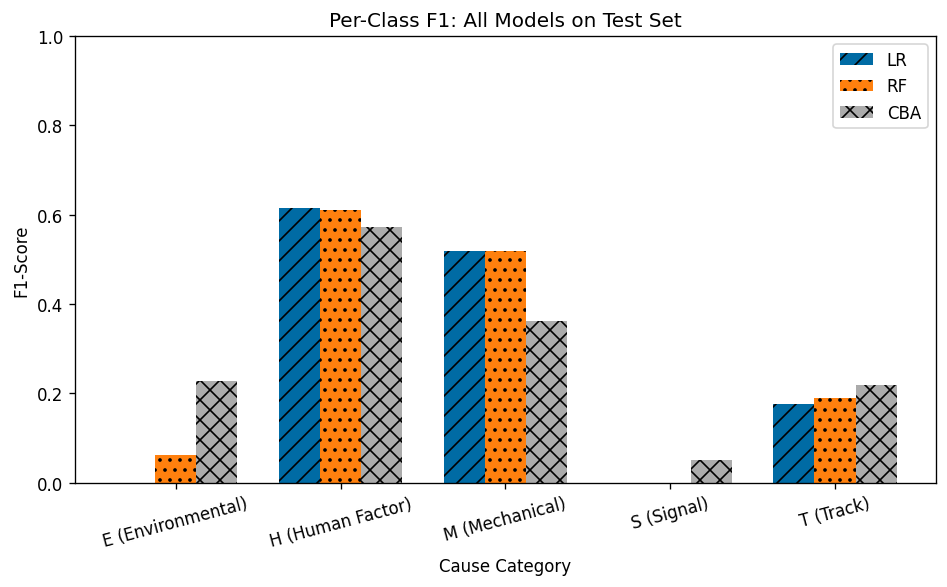

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(CAUSE_ORDER))
width = 0.25
hatches = ['//', '..', 'xx']

models = [('LR', metrics_lr), ('RF', metrics_rf), ('CBA', metrics_cba)]

for i, (name, df) in enumerate(models):
    offset = (i - 1) * width
    bars = ax.bar(x + offset, df['F1'], width, label=name)
    for bar in bars:
        bar.set_hatch(hatches[i])

ax.set_xlabel('Cause Category')
ax.set_ylabel('F1-Score')
ax.set_title('Per-Class F1: All Models on Test Set')
ax.set_xticks(x)
ax.set_xticklabels([f"{c} ({CAUSE_LABELS[c]})" for c in CAUSE_ORDER], rotation=15)
ax.legend()
ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.show()

### Findings: Per-Class F1 Comparison

- LR and RF perform nearly identical on H, M, and T. When a linear model and an ensemble model arrive at the same per-class performance, it reinforces that the features are the limiting factor.
- CBA is the only model with a visible bar for Signal (0.050). And RF's Environmental bar is barely visible (0.061).
- CBA pays for minority class coverage with lower H and M scores. Its Mechanical F1 (0.362) is noticeably shorter than LR/RF (0.519/0.518), showing the tradeoff of redistributing predictions toward rare classes.
- A consistent finding that Track is weak across all three models despite being 22% of the data. Again, suggesting that Track accidents overlap in features with other cause categories.
- The chart visually summarizes the core project finding: traditional models ignore rare classes entirely, while CBA's undersampling strategy produces the only model that attempts to predict all 5 causes as it redistributes predictions from larger categories to rarer categories.

## Confusion Matrices

Side-by-side confusion matrices reveal each model's error patterns. Look for:
- **Diagonal strength:** Which model has the most predictions on the diagonal (correct)?
- **Off-diagonal patterns:** Where does each model misclassify? Do they confuse the same pairs?
- **Column sparsity:** Does the model even attempt to predict certain classes?

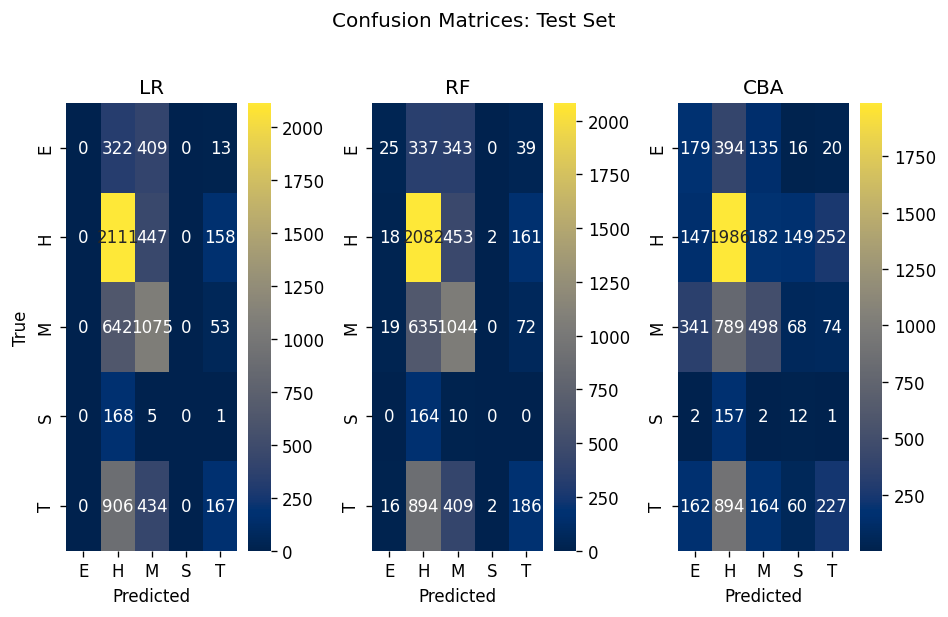

In [20]:
# =====================================================
# UNCOMMENT WHEN READY TO RUN FINAL EVALUATION
# =====================================================
fig, axes = plt.subplots(1, 3, figsize=(8, 5))

predictions = [
    ('LR', y_pred_lr),
    ('RF', y_pred_rf),
    ('CBA', y_pred_cba)
]

for ax, (name, y_pred) in zip(axes, predictions):
    cm = confusion_matrix(y_test, y_pred, labels=CAUSE_ORDER)
    sns.heatmap(cm, annot=True, fmt='d', cmap='cividis',
                xticklabels=CAUSE_ORDER, yticklabels=CAUSE_ORDER, ax=ax)
    ax.set_title(name)
    ax.set_ylabel('True' if name == 'LR' else '')
    ax.set_xlabel('Predicted')

fig.suptitle('Confusion Matrices: Test Set', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

### Findings: Confusion Matrices

- The E (predicted) column is completely empty for LR (all zeros) and nearly empty for RF (25, 18, 19, 0, 16). CBA is the only model that actively predicts Environmental, with 179 correct out of 744 actual Environmental accidents.
- The S (predicted) column is empty for both LR and RF (all zeros). CBA predicts Signal 305 times but only 12 are correct, producing many false positives at 0.039 precision.
- The H column dominates all three models. LR sends 322 Environmental, 642 Mechanical, 168 Signal, and 906 Track accidents into the H bucket. RF shows the same pattern. Both models default to Human Factor when uncertain.
- CBA distributes predictions more evenly across all 5 columns, which is why its H diagonal (1986) is lower than LR (2111) and RF (2082). It sacrifices majority class accuracy to spread predictions across minority classes.
- The M column shows a consistent confusion pattern: all three models misclassify a large number of Track accidents as Mechanical (LR 434, RF 409, CBA 164). This suggests Track and Mechanical accidents share similar feature profiles in the data.
- The diagonal (correct predictions) is brightest for H across all models, reflecting both the class frequency advantage and the models' tendency to favor the majority class.

## Precision-Recall Curves (LR and RF)

PR curves show the precision-recall tradeoff across all decision thresholds. They are more informative than ROC curves for imbalanced datasets because they focus on the positive class performance without being inflated by true negatives. One PR curve per cause category, per model.

CBA is excluded because it uses first-match rule classification and does not produce probability estimates.

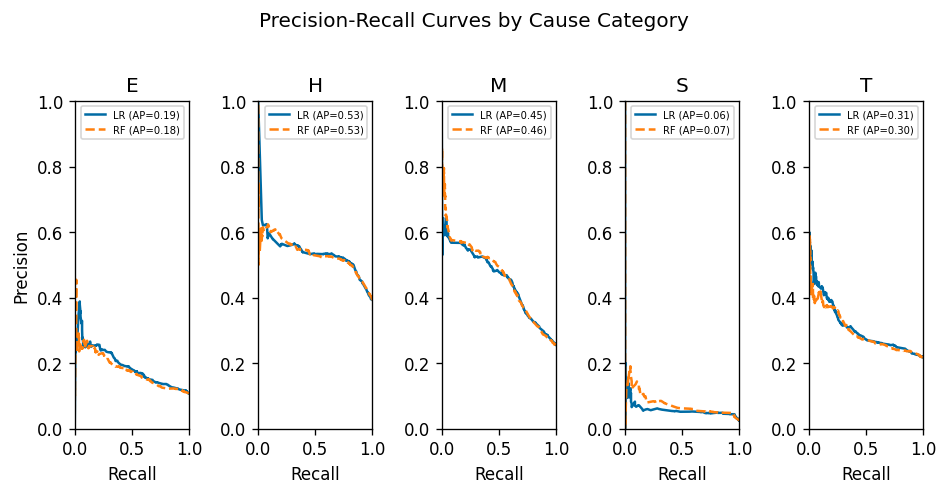

In [ ]:
from sklearn.preprocessing import label_binarize

# Binarize test labels for PR curves
y_test_bin = label_binarize(y_test, classes=CAUSE_ORDER)

# Get probability estimates
y_prob_lr = lr_pipeline.predict_proba(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)

fig, axes = plt.subplots(1, 5, figsize=(8, 4))

for i, cause in enumerate(CAUSE_ORDER):
    ax = axes[i]
    
    # LR
    p_lr, r_lr, _ = precision_recall_curve(y_test_bin[:, i], y_prob_lr[:, i])
    ap_lr = average_precision_score(y_test_bin[:, i], y_prob_lr[:, i])
    ax.plot(r_lr, p_lr, linewidth=1.5, label=f'LR (AP={ap_lr:.2f})')
    
    # RF
    p_rf, r_rf, _ = precision_recall_curve(y_test_bin[:, i], y_prob_rf[:, i])
    ap_rf = average_precision_score(y_test_bin[:, i], y_prob_rf[:, i])
    ax.plot(r_rf, p_rf, linewidth=1.5, linestyle='--', label=f'RF (AP={ap_rf:.2f})')
    
    ax.set_title(f'{cause}')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=6)
    if i == 0:
        ax.set_ylabel('Precision')
    ax.set_xlabel('Recall')

fig.suptitle('Precision-Recall Curves by Cause Category', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

### PR Curve Findings: Per Cause Category

The Precision-Recall curves confirm that LR and RF perform nearly identically across all 5 cause categories, with Average Precision (AP) scores within 0.01-0.02 of each other for every class.

**Human Factor (H):** Strongest performance from both models (AP = 0.53). The curves hold precision above 0.60 until roughly 0.40 recall, then decline steadily. This is the majority class (39%) so higher AP is expected.

**Mechanical (M):** Second strongest (AP = 0.45-0.46). Similar curve shape to H but drops off earlier. Both models can identify Mechanical accidents with moderate reliability.

**Track (T):** Moderate performance (AP = 0.30-0.31). The curves show precision starting around 0.55 but dropping quickly as recall increases. Both models struggle to capture Track accidents without generating false positives.

**Environmental (E):** Weak performance (AP = 0.18-0.19). Precision never exceeds 0.40 and drops to 0.10-0.15 across most recall levels. The 11% class frequency makes it difficult for either model to distinguish Environmental accidents from the majority classes.

**Signal (S):** Near-zero performance (AP = 0.06-0.07). The curves barely rise above the baseline. At 2.5% of the dataset, Signal accidents are effectively invisible to both models at any threshold.

**Key takeaway:** The near-identical AP scores between LR and RF across all 5 classes reinforces the finding from tuning experiments: the performance ceiling is set by the features, not the algorithm. A linear model and a nonlinear model produce the same precision-recall tradeoffs for every cause category.

---

# Section 3: Error Analysis

Understanding where models fail is as valuable as knowing where they succeed. This section examines prediction agreement, shared errors, and feature patterns in misclassified rows.

## Model Agreement

How often do all three models agree on a prediction? When they disagree, which models tend to align?

In [ ]:
# Build agreement DataFrame
agreement = pd.DataFrame({
    'true': y_test.values,
    'lr': y_pred_lr,
    'rf': y_pred_rf,
    'cba': y_pred_cba
})

# All three agree
all_agree = (agreement['lr'] == agreement['rf']) & (agreement['rf'] == agreement['cba'])
all_correct = all_agree & (agreement['lr'] == agreement['true'])
all_wrong = all_agree & (agreement['lr'] != agreement['true'])

print(f"All three models agree: {all_agree.sum()} / {len(agreement)} ({all_agree.mean():.1%})")
print(f"  All agree AND correct: {all_correct.sum()} ({all_correct.mean():.1%})")
print(f"  All agree AND wrong:   {all_wrong.sum()} ({all_wrong.mean():.1%})")
print(f"  At least one disagrees: {(~all_agree).sum()} ({(~all_agree).mean():.1%})")

# Pairwise agreement
lr_rf = (agreement['lr'] == agreement['rf']).mean()
lr_cba = (agreement['lr'] == agreement['cba']).mean()
rf_cba = (agreement['rf'] == agreement['cba']).mean()

print(f"\nPairwise agreement:")
print(f"  LR-RF:  {lr_rf:.1%}")
print(f"  LR-CBA: {lr_cba:.1%}")
print(f"  RF-CBA: {rf_cba:.1%}")

All three models agree: 4716 / 6911 (68.2%)
  All agree AND correct: 2424 (35.1%)
  All agree AND wrong:   2292 (33.2%)
  At least one disagrees: 2195 (31.8%)

Pairwise agreement:
  LR-RF:  90.2%
  LR-CBA: 72.4%
  RF-CBA: 70.1%


### Findings: Model Agreement

- All three models agree on 68.2% of test rows, but they're wrong nearly as often as they're right (2292 wrong vs 2424 correct). A third of the entire test set consists of accidents that all three models confidently misclassify together. This is not a model problem - these are rows where the 5 features genuinely cannot distinguish the cause.
- LR and RF agree 90.2% of the time despite being fundamentally different algorithms. A linear model and a 300-tree ensemble see the same data and reach the same conclusion 9 out of 10 times. This is strong evidence that the feature set, not the algorithm, determines the prediction.
- CBA disagrees with LR and RF on roughly 28-30% of predictions. This is where undersampling creates value - CBA makes different calls on rows that LR and RF would default to Human Factor, and some of those different calls are correct for minority classes that the other models completely miss.
- The 31.8% disagreement zone is where model selection actually matters. For the other 68.2%, it doesn't matter which model you deploy - they all say the same thing.

## Shared Errors

When all three models make the same wrong prediction, the error is likely caused by genuinely ambiguous data rather than a model weakness. Examining these cases reveals the limits of what 5 categorical features can distinguish.

In [ ]:
# Rows where all three agree but are wrong
shared_errors = agreement[all_wrong].copy()
shared_errors_full = df_test.loc[shared_errors.index, feature_cols + [target]].copy()
shared_errors_full['predicted'] = shared_errors['lr'].values

print(f"Shared errors: {len(shared_errors_full)} rows")
print(f"\nTrue vs Predicted distribution in shared errors:")
error_crosstab = pd.crosstab(shared_errors_full[target], shared_errors_full['predicted'],
                              margins=True)
print(error_crosstab)

print(f"\nMost common feature combinations in shared errors:")
top_patterns = shared_errors_full.groupby(feature_cols).size().sort_values(ascending=False).head(10)
print(top_patterns)

Shared errors: 2292 rows

True vs Predicted distribution in shared errors:
predicted          H    M    T   All
Cause_Category                      
E                288  118    7   413
H                  0  176   93   269
M                528    0   23   551
S                156    2    0   158
T                742  159    0   901
All             1714  455  123  2292

Most common feature combinations in shared errors:
Weather Condition  Track Type  Visibility  Region   RUCC_Metro_Adjacency
Clear              Yard        Day         South    Metro                   176
                               Dark        South    Metro                   164
                               Day         Midwest  Metro                   123
                               Dark        Midwest  Metro                   117
                   Main        Day         South    Metro                   111
Cloudy             Yard        Day         South    Metro                    79
Clear              Yard 

### Findings: Shared Errors

- 74.8% of shared errors (1714 of 2292) are misclassified as Human Factor. H is not just the majority class - it is the default prediction when the feature profile provides no distinguishing signal. The models aren't learning H, they're falling back to it.
- Track accidents produce the most shared errors (901 rows), with 742 dumped into H. This means nearly 60% of all Track accidents in the test set look identical to Human Factor accidents given these 5 features. Track and H may genuinely require different features to separate.
- The top 10 most common error patterns are all Metro, mostly Yard track, mostly Clear weather. These are the most "normal" accident profiles in the dataset - nothing unusual about the weather, visibility, track type, or location. When everything looks typical, the models have nothing to differentiate causes.
- 6 of the top 10 error patterns involve Yard track specifically. Yards are operationally complex environments where Human Factor, Mechanical, and Track failures all occur under similar conditions. The features we have describe the environment but not the operational context that distinguishes causes within that environment.
- The shared error patterns suggest that improving classification would require features that describe what was happening at the time of the accident (speed, tonnage, equipment type, time of day) rather than just where and under what conditions it happened.

---

# Section 4: Conclusions and Recommendations

## Model Comparison Summary

Three classification approaches - LR, RF, and CBA - were trained on the same 5 categorical features and evaluated on a locked test set of 6,911 accidents. RF scored highest at 0.420 weighted F1, followed by LR at 0.413 and CBA at 0.391. The 0.029 spread confirms the feature set determines performance, not the algorithm.

## Key Findings

1. **Overall performance:** RF edged LR by 0.007 Weighted F1. More meaningful is a linear model and a 300-tree ensemble hit the same ceiling on these features.

2. **CV to test consistency:** LR (+0.004) and RF (-0.001) held steady. CBA dropped 0.026 due to undersampling variance. All deltas under 0.03.

3. **Minority class handling:** CBA is the only model that predicts all 5 causes. Environmental: CBA 0.227 F1 vs LR 0.000 and RF 0.061. Signal: CBA 0.050 F1 vs 0.000 for both LR and RF.

4. **Interpretability:** ARM produces 51 human-readable rules. "Industry track + Cloudy = Track failure." While LR and RF cannot explain individual predictions.

5. **Accident Type:** Removing this featured dropped all three models 0.08-0.13 in F1. ARM first exposed the dominance, Chi-Square confirmed it. Methodologically correct - classifying by outcome has no prevention value.

## Which Model Would We Deploy?

- **Maximizing accuracy:** RF (0.420), though the margin over LR is negligible
- **Detecting rare causes:** CBA, the only model that attempts all 5 classes
- **Explainability:** CBA, which produces actionable if-then rules

No single model wins on all criteria.

## Limitations

- 5 categorical features cannot distinguish cause categories within common accident profiles
- Signal (2.5%) and Environmental (11%) lack enough distinct patterns for traditional models
- Accident Type removal was correct but dropped performance from ~0.50-0.55 to ~0.39-0.42
- CBA undersampling introduces variance (-0.026 CV-to-test delta)
- The 5-feature constraint may have excluded informative FRA features

## Future Work

- Entity embeddings (Guo & Berkhahn, 2016) on all available FRA features with clustering to test whether dense representations better separate rare causes
- Expanded feature set: speed, tonnage, equipment type, time of day
- Integration with Matt and Tim's regression models for damage cost prediction